In [ ]:
X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y = [5, 6, 7, 8, 7, 9, 10, 10, 11, 12]

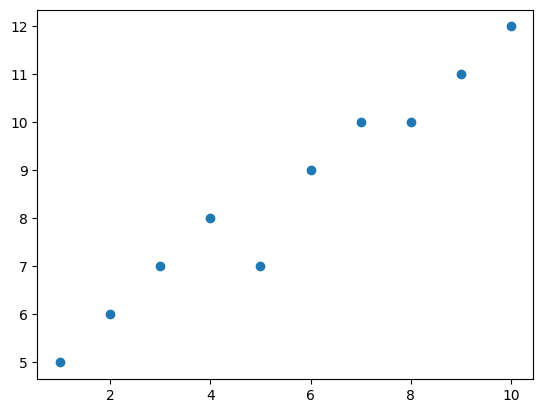

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X,Y)
plt.show()

In [ ]:
def pearson_correlation(X, Y):
    n=len(X)
    mx=sum(X)/n
    my=sum(Y)/n
    num=sum((X[i]-mx)*(Y[i]-my) for i in range(n))
    den=(sum((X[i]-mx)**2 for i in range(n))*sum((Y[i]-my)**2 for i in range(n)))**0.5
    return num/den

In [ ]:
def spearman_rank_correlation(X, Y):
    def rank(a):
        s=sorted((v,i) for i,v in enumerate(a))
        r=[0]*len(a)
        i=0
        while i<len(s):
            j=i
            while j<len(s) and s[j][0]==s[i][0]:
                j+=1
            avg=(i+j-1)/2+1
            for k in range(i,j):
                r[s[k][1]]=avg
            i=j
        return r
    rx=rank(X)
    ry=rank(Y)
    n=len(X)
    d=sum((rx[i]-ry[i])**2 for i in range(n))
    return 1-(6*d)/(n*(n**2-1))


In [ ]:
from scipy.stats import spearmanr


In [ ]:
X=[10,20,30,40,50,60,70]
Y=[8,18,28,42,48,63,70]

p=pearson_correlation(X,Y)
s=spearman_rank_correlation(X,Y)
scipy_s=spearmanr(X,Y).correlation

print(p)
print(s)
print(scipy_s)


0.9970456495219482
1.0
1.0


In [ ]:
import math

def difference_significance_test(r,n):
    t=r*math.sqrt((n-2)/(1-r*r))
    return t


In [ ]:
# Q1
Y1=[70,65,90,95,110,115,120,140,155,150]
X1=[80,100,120,140,160,180,200,220,240,260]

r1=pearson_correlation(X1,Y1)
t1=difference_significance_test(r1,len(X1))

print("Q1 Pearson r:",r1)
print("Q1 t value:",t1)


Q1 Pearson r: 0.9808473685985792
Q1 t value: 14.243171154216359


In [ ]:
# Q2
Y2=[60,90,110,125,150,170,180,200,220,230,240,250,255,260,260]
X2=[100,150,200,250,300,350,400,450,500,550,600,650,700,750,800]

r2=pearson_correlation(X2,Y2)
t2=difference_significance_test(r2,len(X2))

print("Q2 Pearson r:",r2)
print("Q2 t value:",t2)


Q2 Pearson r: 0.9765884824912036
Q2 t value: 16.368555733381434


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


In [ ]:
X=np.array([140,155,159,179,192,200,212])
Y=np.array([60,62,67,70,71,72,75])


In [ ]:
n=len(X)
mx=X.mean()
my=Y.mean()
b1=np.sum((X-mx)*(Y-my))/np.sum((X-mx)**2)
b0=my-b1*mx
print("Manual intercept:",b0)
print("Manual slope:",b1)


Manual intercept: 32.78300590740486
Manual slope: 0.20009616705591424


In [ ]:
model=LinearRegression().fit(X.reshape(-1,1),Y)
print("Model intercept:",model.intercept_)
print("Model slope:",model.coef_[0])
print("Model R2:",model.score(X.reshape(-1,1),Y))


Model intercept: 32.78300590740484
Model slope: 0.20009616705591435
Model R2: 0.9311184259327128


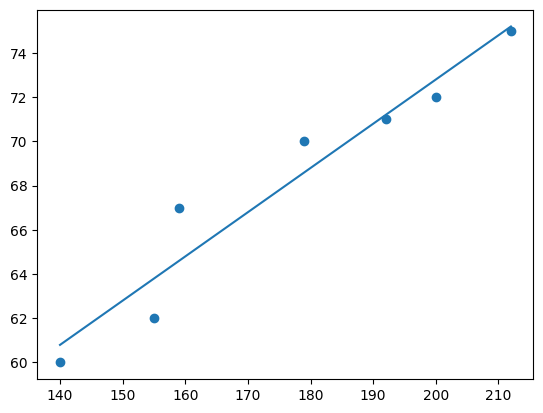

In [ ]:
Y_pred=b0+b1*X
plt.scatter(X,Y)
plt.plot(X,Y_pred)
plt.show()


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

Y=np.array([140,155,159,179,192,200,212,215])
X1=np.array([60,62,67,70,71,72,75,78])
X2=np.array([22,25,24,20,15,14,14,11])
X=np.column_stack((X1,X2))

model=LinearRegression().fit(X,Y)
print("Model intercept:",model.intercept_)
print("Model coefficients:",model.coef_)


Model intercept: -6.867487247726785
Model coefficients: [ 3.1478931  -1.65614327]


In [ ]:
import numpy as np
import math
from sklearn.linear_model import LinearRegression

Y=np.array([70,65,90,95,110,115,120,140,155,150])
X=np.array([80,100,120,140,160,180,200,220,240,260])
n=len(X)

mean_x=X.mean()
mean_y=Y.mean()

b1=np.sum((X-mean_x)*(Y-mean_y))/np.sum((X-mean_x)**2)
b0=mean_y-b1*mean_x
print("Consumption function: Y =",b0,"+",b1,"X")

Consumption function: Y = 24.454545454545467 + 0.509090909090909 X


In [ ]:
Y_pred=b0+b1*X
sse=np.sum((Y-Y_pred)**2)
se=np.sqrt(sse/(n-2))
sb1=se/np.sqrt(np.sum((X-mx)**2))
t_b1=b1/sb1
print("t statistic for beta1:",t_b1)

t statistic for beta1: 14.340129835366643


In [ ]:
sst=np.sum((Y-my)**2)
r2=1-sse/sst
print("R squared:",r2)


R squared: 0.9876263552711019


In [ ]:
Y=np.array([60,90,110,125,150,170,180,200,220,230,240,250,255,260,260])
X=np.array([100,150,200,250,300,350,400,450,500,550,600,650,700,750,800])
n=len(X)

mean_x=X.mean()
mean_y=Y.mean()
b1=np.sum((X-mean_x)*(Y-my))/np.sum((X-mean_x)**2)
b0=my-b1*mean_x
print("Food expenditure equation: Y =",b0,"+",b1,"X")



Food expenditure equation: Y = -62.83928571428572 + 0.2910714285714286 X


In [ ]:
Y_pred=b0+b1*X
sse=np.sum((Y-Y_pred)**2)
se=np.sqrt(sse/(n-2))
sb1=se/np.sqrt(np.sum((X-mx)**2))
t_b1=b1/sb1
print("t statistic for beta1:",t_b1)

sst=np.sum((Y-my)**2)
r2=1-sse/sst
print("R squared:",r2)

t statistic for beta1: 3.063680089540246
R squared: 0.21731559763793318
